# 5장 2강: 검정력 분석과 MDE 기반 표본 크기 산정 — 실습문제

## 실습 목표

- 기준 유지율과 MDE를 효과 크기로 변환하여 그룹당 필요 표본을 계산합니다.
- 유의수준, 검정력, MDE, 표본 크기의 관계를 설명합니다.
- MDE 변화에 따른 필요 표본과 예상 실험 기간을 비교합니다.
- 실제 트래픽과 운영 기간을 반영해 실험 설계의 실행 가능성을 판단합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, statsmodels, Matplotlib
- `cookie_cats.csv`
- 핵심 지표: `retention_7`
- 대조군: `gate_30`, 실험군: `gate_40`
- 양측검정, 유의수준 $\alpha=0.05$, 목표 검정력 0.80, 1:1 배정을 기본 조건으로 사용합니다.

> 현재 데이터의 `gate_30` 7일 유지율을 기준선의 **학습용 대리값**으로 사용합니다. 실제 신규 실험에서는 실험 결과가 아닌 과거 데이터나 사전 조사로 기준선을 정해야 합니다.

## 실습 준비

아래 셀을 실행하여 데이터와 분석 환경을 준비하세요.


In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
if "Malgun Gothic" in {f.name for f in font_manager.fontManager.ttflist}:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

data_candidates = [Path("data/cookie_cats.csv"), Path("cookie_cats.csv"), Path("upload/cookie_cats.csv")]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("프로젝트 루트에서 실행하고 data/cookie_cats.csv를 확인하세요.")
df = pd.read_csv(data_path)
alpha, target_power = 0.05, 0.80
print("데이터 크기:", df.shape)
print("전체 결측치 수:", int(df.isna().sum().sum()))
print(df.version.value_counts().reindex(["gate_30", "gate_40"]))
assert df.userid.is_unique and df.retention_7.notna().all()


데이터 크기: (90189, 5)
전체 결측치 수: 0
version
gate_30    44700
gate_40    45489
Name: count, dtype: int64


---

## 필수 1. 7일 유지율의 절대 1%p 증가를 탐지할 표본 크기 계산

`gate_30`의 관측 7일 유지율을 기준선으로 사용하여, 유지율이 절대 1%p 증가하는 효과를 탐지할 표본 크기를 계산하세요.

### 수행 요구사항

1. `gate_30`의 `retention_7` 평균을 기준 유지율로 계산하세요.
2. MDE를 `0.01`로 설정하고 목표 유지율을 계산하세요.
3. `proportion_effectsize()`로 효과 크기를 구하세요.
4. `NormalIndPower().solve_power()`로 그룹당 필요 표본을 계산하세요.
5. 표본 수는 소수점 이하를 올림하고, 전체 필요 표본도 계산하세요.
6. 현재 데이터의 두 그룹 중 더 작은 표본 수와 비교하세요.

### 질문

- 검정력 0.80은 무엇을 의미하나요?
- MDE 1%p는 상대적으로 1% 증가한다는 뜻인가요?
- 계산된 표본을 반올림하지 않고 올림해야 하는 이유는 무엇인가요?
- 현재 데이터는 수치상 필요한 표본을 충족하나요?


In [2]:
baseline = df.loc[df.version == "gate_30", "retention_7"].mean()
mde = 0.01
target_rate = baseline + mde
power_model = NormalIndPower()

def sample_size_for_mde(mde):
    assert 0 < baseline < baseline + mde < 1
    effect = abs(proportion_effectsize(baseline + mde, baseline))
    raw_n = power_model.solve_power(effect_size=effect, alpha=alpha, power=target_power,
                                    ratio=1.0, alternative="two-sided")
    return effect, raw_n, math.ceil(raw_n)

effect_size, raw_n, n_per_group = sample_size_for_mde(mde)
min_current = int(df.version.value_counts().min())
print(f"기준 유지율={baseline:.6%}, 목표 유지율={target_rate:.6%}")
print(f"Cohen h={effect_size:.6f}, 그룹당 계산값={raw_n:.4f}")
print(f"그룹당 필요 표본={n_per_group:,}, 전체 필요 표본={2*n_per_group:,}")
print(f"현재 작은 그룹={min_current:,}, 표본 충족={min_current >= n_per_group}")
assert power_model.power(effect_size=effect_size, nobs1=n_per_group, alpha=alpha, ratio=1.0) >= target_power


기준 유지율=19.020134%, 목표 유지율=20.020134%
Cohen h=0.025232, 그룹당 계산값=24657.1414
그룹당 필요 표본=24,658, 전체 필요 표본=49,316
현재 작은 그룹=44,700, 표본 충족=True


### 필수 1 답변

- **검정력 0.80:** 설정한 기준선과 실제 효과(여기서는 +1%p), 검정 가정이 맞을 때 반복 실험에서 H0를 기각할 확률이 약 80%라는 뜻입니다. H1이 참일 확률이나 실험 성공 확률을 보장하는 값이 아닙니다.
- **절대 변화:** 기준 19.0201%에 0.01을 더해 20.0201%가 되는 변화입니다. 상대 1% 증가라면 기준선×1.01이며 서로 다릅니다.
- **올림:** 반올림으로 계산 필요량 아래로 내려가 목표 검정력에 못 미치는 일을 피하기 위해서입니다. 그룹당 24,658명, 전체 49,316명이 필요합니다.
- **현재 표본:** 작은 그룹 44,700명도 24,658명 이상이므로 수치상 충족합니다. 이는 지정 효과에 대한 설계 비교이며 관측 효과가 유의하거나 실제로 존재함을 보장하지 않습니다.

---

## 필수 2. MDE별 표본 크기와 실험 기간 비교

MDE를 `0.5%p`, `1.0%p`, `1.5%p`, `2.0%p`로 바꾸어 필요한 표본과 기간을 비교하세요. 하루 전체 실험 대상 트래픽은 6,000명이고 A/B에 절반씩 배정한다고 가정합니다.

### 수행 요구사항

1. 각 MDE의 효과 크기와 그룹당 필요 표본을 계산하세요.
2. 전체 필요 표본과 예상 실험 일수를 계산하세요.
3. 계산 결과를 DataFrame으로 정리하세요.
4. MDE별 그룹당 필요 표본을 막대그래프로 나타내세요.
5. 최대 운영 가능 기간이 14일일 때 각 설계의 실행 가능 여부를 표시하세요.

### 질문

- MDE가 작아질수록 표본 크기와 기간은 어떻게 변하나요?
- 네 가지 설계 중 14일 안에 완료할 수 없는 것은 무엇인가요?
- 표본을 줄이기 위해 MDE를 무조건 크게 설정해도 되나요?
- MDE는 어떤 근거로 정해야 하나요?


,MDE (%p),Cohen h,그룹당 표본,전체 표본,모집 일수,14일 내 모집 가능,7일 관찰 포함 일수
0,0.5,0.012677,97679,195358,33,False,40
1,1.0,0.025232,24658,49316,9,True,16
2,1.5,0.037669,11063,22126,4,True,11
3,2.0,0.049995,6281,12562,3,True,10


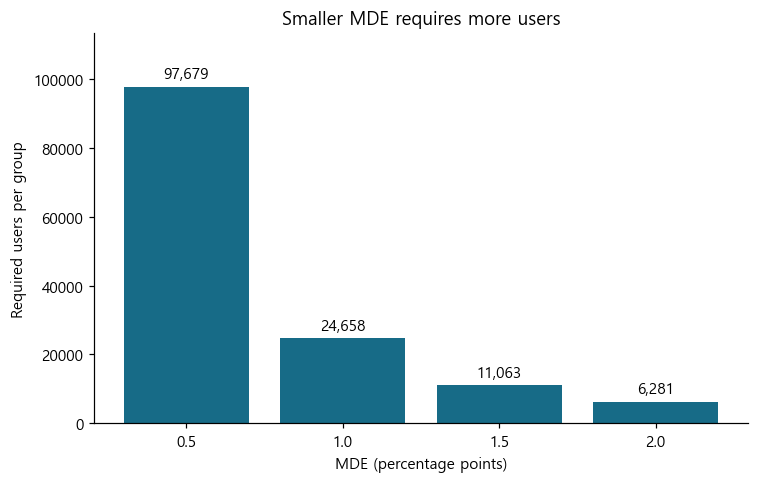

모집 일수는 매일 신규 적격 고유 사용자 유입을 가정합니다. 최종 7일 유지율 판정에는 추가 관찰 기간이 필요합니다.


In [3]:
daily_total, max_days = 6000, 14
rows = []
for candidate in [0.005,0.01,0.015,0.02]:
    effect, raw_n, n = sample_size_for_mde(candidate)
    days = math.ceil(2*n/daily_total)
    rows.append({"MDE (%p)": candidate*100, "Cohen h": effect, "그룹당 표본": n,
                 "전체 표본": 2*n, "모집 일수": days, "14일 내 모집 가능": days <= max_days,
                 "7일 관찰 포함 일수": days+7})
mde_table = pd.DataFrame(rows)
display(mde_table)
fig,ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(mde_table["MDE (%p)"].astype(str),mde_table["그룹당 표본"],color="#176B87")
ax.bar_label(bars, labels=[f"{n:,}" for n in mde_table["그룹당 표본"]],padding=3)
ax.set(xlabel="MDE (percentage points)",ylabel="Required users per group",title="Smaller MDE requires more users")
ax.set_ylim(0,mde_table["그룹당 표본"].max()*1.16)
fig.tight_layout()
plt.show()
print("모집 일수는 매일 신규 적격 고유 사용자 유입을 가정합니다. 최종 7일 유지율 판정에는 추가 관찰 기간이 필요합니다.")


### 필수 2 답변

- **MDE와 표본:** 더 작은 효과를 구분하려면 더 많은 표본과 더 긴 모집 기간이 필요합니다. 비슷한 기준선에서는 필요 표본이 대략 MDE 제곱에 반비례합니다.
- **14일 제약:** 0.5%p 설계는 14일 내 모집할 수 없고, 1.0·1.5·2.0%p 설계는 모집 기준으로 가능합니다. `7일 관찰 포함 일수` 열을 통해 14일이 최종 결과 판정까지의 기한인 경우도 별도로 판단해야 합니다.
- **무조건 큰 MDE:** 허용되지 않습니다. 표본은 줄지만 사업상 의미 있는 작은 효과를 놓칠 가능성이 커집니다. MDE 미만의 효과가 절대로 검출되지 않는 것은 아니며, 설정한 목표 검정력을 보장할 설계 대상이 아니라는 뜻입니다.
- **설정 근거:** 사용자·매출 가치, 도입 비용과 위험, 과거 기준 유지율, 확보 가능한 신규 트래픽과 기간을 함께 고려해 사전에 정합니다. 관측된 결과에 맞춰 유리하게 바꾸면 안 됩니다.

유의수준을 더 작게 하거나 목표 검정력을 더 높이면 동일 효과를 탐지하는 데 더 많은 표본이 필요합니다. 모집 일수에 7일을 더한 값은 마지막 모집자의 관찰 완료를 기다리는 계획상 근사이며 실제 이벤트 집계 지연도 반영해야 합니다.

---

## 과제. 운영 제약을 반영한 Cookie Cats 표본 설계

다음 운영 조건에서 MDE 후보 `1.0%p`와 `1.5%p`를 비교하고 실행안을 선택하세요.

### 운영 조건

- 기준 7일 유지율: `gate_30` 관측값
- 유의수준: 0.05
- 목표 검정력: 0.80
- 양측검정, 1:1 배정
- 하루 전체 실험 대상 사용자: 5,000명
- 최대 운영 기간: 7일
- 데이터 누락·이탈 대비 여유 표본: 10%
- 비즈니스적으로 의미 있는 최소 변화: 1.5%p

### 수행 요구사항

1. 두 MDE 후보의 기본 그룹당 표본을 계산하세요.
2. 기본 표본을 `0.90`으로 나누어 10% 누락을 고려한 그룹당 모집 목표를 계산하고 올림하세요.
3. 전체 모집 목표와 예상 기간을 계산하세요.
4. 7일 안에 실행 가능한지 판단하세요.
5. 아래 질문을 포함하여 5~7문장의 최종 결론을 작성하세요.

### 질문

- 어떤 MDE 설계를 선택해야 하나요?
- 선택한 설계가 통계적 조건과 비즈니스 기준을 모두 만족하나요?
- 선택하지 않은 설계는 왜 현재 운영 조건에 맞지 않나요?
- 실제 실행 전에 추가로 확인해야 할 사항은 무엇인가요?

> 과제는 필수 문제와 동일한 수준이며, 제시된 조건을 같은 계산 절차에 적용하면 됩니다.


In [4]:
daily_total, max_days, usable_fraction = 5000, 7, 0.90
business_mde = 0.015
operation_rows = []
for candidate in [0.01,0.015]:
    effect, raw_n, base_n = sample_size_for_mde(candidate)
    recruit_n = math.ceil(base_n/usable_fraction)
    total_n = 2*recruit_n
    days = math.ceil(total_n/daily_total)
    operation_rows.append({"MDE (%p)": 100*candidate, "기본 그룹당 표본": base_n,
        "그룹당 모집 목표": recruit_n, "전체 모집 목표": total_n,
        "모집 일수": days, "7일 내 모집 가능": days <= max_days,
        "7일 관찰 포함 일수": days+7})
operation_table = pd.DataFrame(operation_rows)
display(operation_table)
print("선택: 사업 기준인 1.5%p를 탐지하는 설계. 단, 7일을 모집 기간으로 해석할 때 실행 가능합니다.")
print("7일이 최종 판정까지의 총기간이면 두 안 모두 어렵고, 관찰기간 연장이 필요합니다.")


,MDE (%p),기본 그룹당 표본,그룹당 모집 목표,전체 모집 목표,모집 일수,7일 내 모집 가능,7일 관찰 포함 일수
0,1.0,24658,27398,54796,11,False,18
1,1.5,11063,12293,24586,5,True,12


선택: 사업 기준인 1.5%p를 탐지하는 설계. 단, 7일을 모집 기간으로 해석할 때 실행 가능합니다.
7일이 최종 판정까지의 총기간이면 두 안 모두 어렵고, 관찰기간 연장이 필요합니다.


### 과제 결론 (6문장)

최대 7일을 **모집 기간**으로 해석하면 비즈니스 기준과 같은 **MDE 1.5%p 설계**를 선택합니다.
이 안은 기본 그룹당 11,063명에 누락률 10%를 반영하여 그룹당 12,293명, 전체 24,586명을 모집해야 하며 예상 모집 기간은 5일입니다.
기준선과 독립적 관측·1:1 배정 가정 아래 양측 α=0.05와 목표 검정력 0.80을 충족하도록 설계되고, 사업상 의미 있는 최소 변화 1.5%p를 탐지 대상으로 삼습니다.
1.0%p 안은 기본 그룹당 24,658명, 누락 반영 모집 목표 그룹당 27,398명으로 전체 54,796명이 필요해 11일이 걸리므로 현재 모집 제약에 맞지 않습니다.
실행 전 기준선의 적합성, 매일 5,000명이 재방문을 제외한 적격 신규 고유 사용자인지, 실제 배정비와 누락 원인 및 집단별 누락률을 확인해야 하며 단순 10% 증원으로 선택 편향이 해결되지는 않습니다.
마지막 사용자의 7일 유지율까지 보려면 선택안도 모집 시작부터 약 12일이 필요하므로 7일이 최종 분석까지 포함한 총기한이라면 두 안 모두 그대로 실행할 수 없고 관찰 기간을 연장해야 합니다.

---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

표본 크기를 감으로 정했을 때의 문제와, 기준선·MDE·검정력·트래픽·운영 기간을 연결하면서 설계가 어떻게 개선되었는지 정리하세요.

### 마무리 답변

1. 표본 수를 감으로 정하면 의미 있는 효과를 놓치거나, 필요 표본은 모아도 관찰 기간이 부족한 실험을 설계할 수 있습니다.

2. 학습용 기준선, 절대 MDE, 양측 α=0.05, 검정력 0.80, 배정비, 고유 사용자 유입량, 누락률을 연결해 모집 수와 기간을 계산했습니다.

3. 1.0%p 안은 누락 반영 후 11일, 1.5%p 안은 5일 모집이 필요하여 운영 가능성이 구분됩니다. 선택안도 7일 유지율 관찰까지는 약 12일이며, 표본 증가만으로 체계적인 데이터 누락 편향을 해결할 수는 없습니다.
